In [1]:
#import sys
#!{sys.executable} -m pip install wordcloud

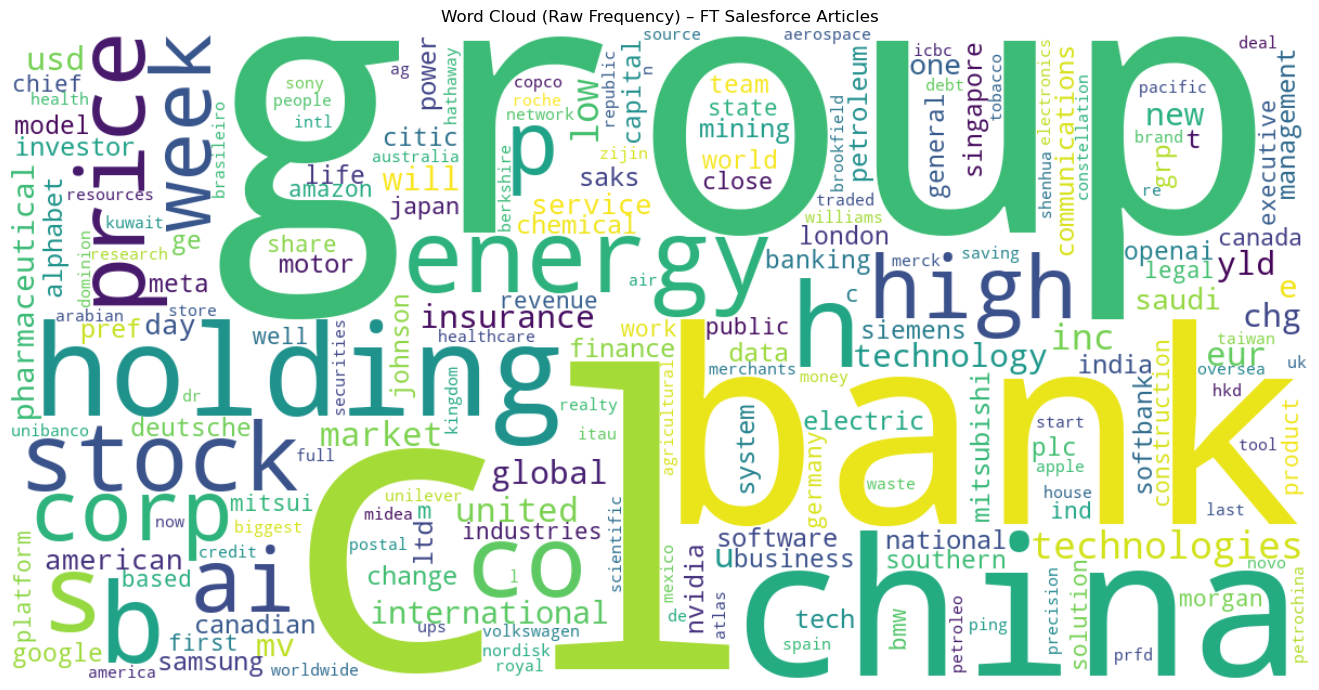

C:\Users\ShrutiPunjabi\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


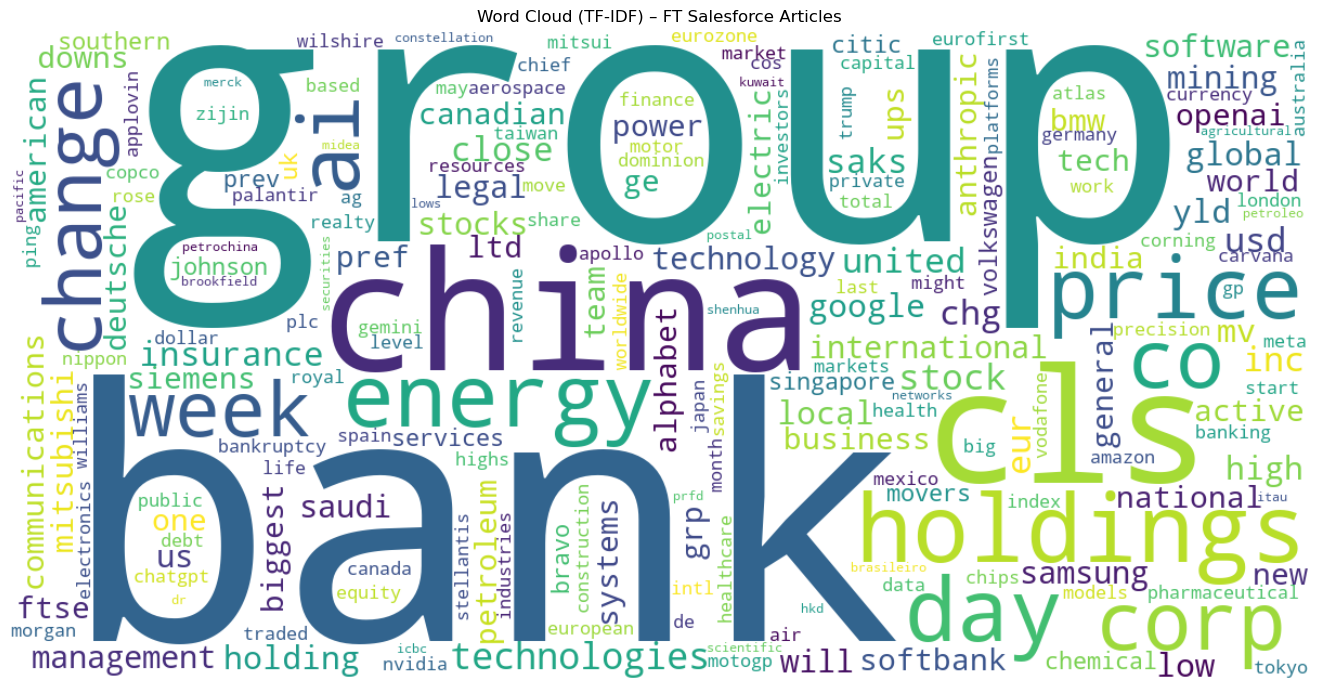

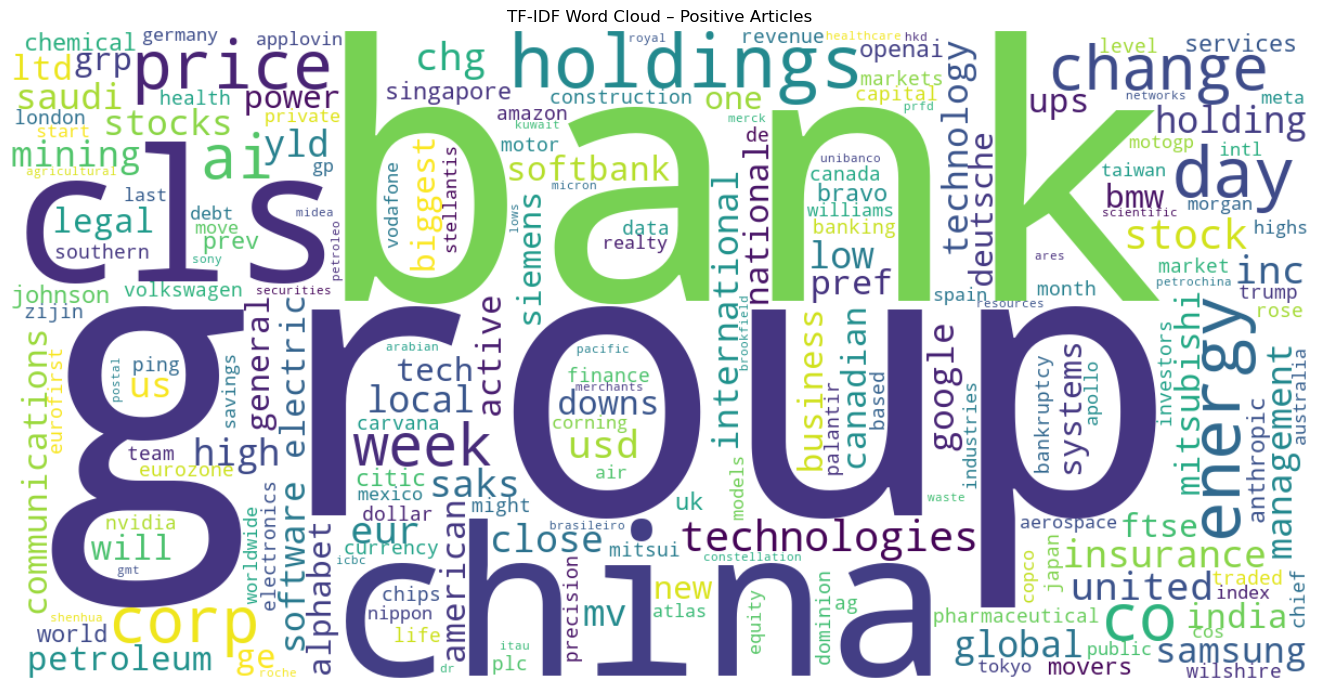

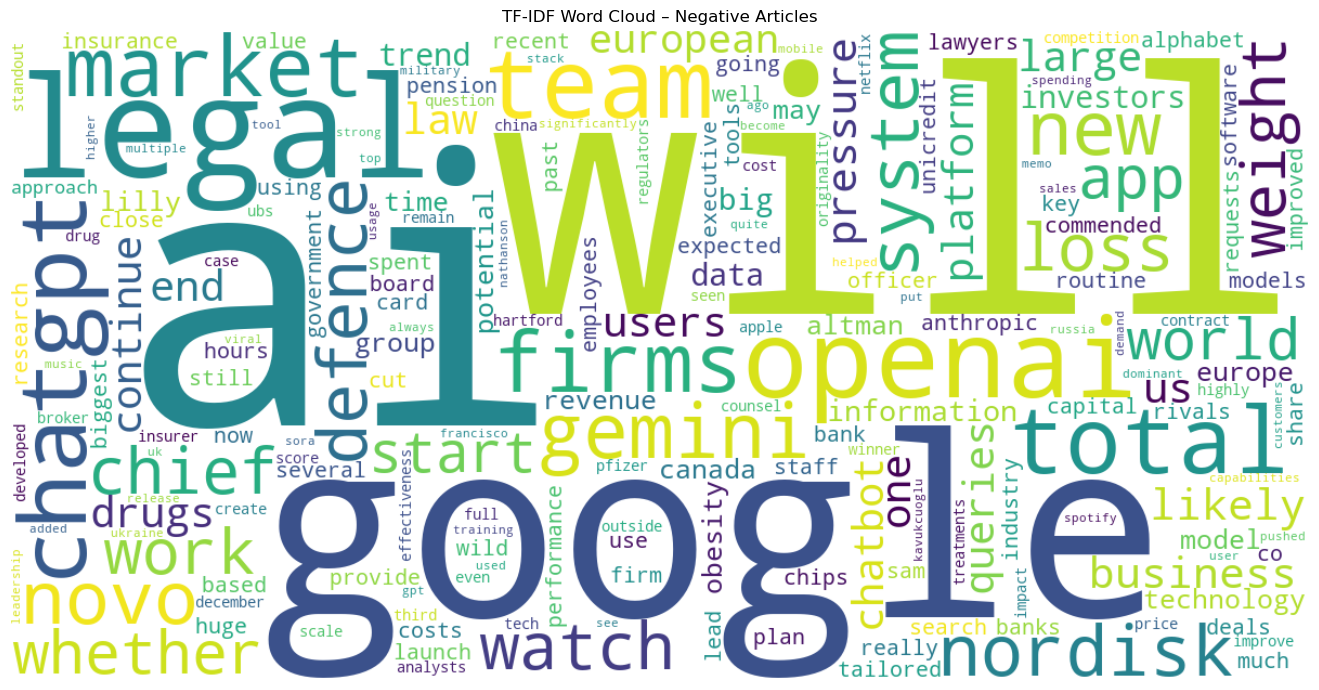

Saved all word clouds and top term tables.


In [2]:
# -*- coding: utf-8 -*-
"""
FT Salesforce Word Cloud + TF-IDF Analysis
Corresponds exactly to lecture slides.
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer

# ---------------------------------------------------
# 1. Load Sentiment Data
# ---------------------------------------------------
df = pd.read_csv("ft_salesforce_sentiment.csv")

if "text" not in df.columns or "sentiment_score" not in df.columns:
    raise ValueError("Need columns: text, sentiment_score")

# ---------------------------------------------------
# 2. Clean Text
# ---------------------------------------------------
def clean_text(text: str) -> str:
    text = str(text).lower()

    # remove possessives
    text = re.sub(r"'s\b", "", text)
    text = text.replace("'", " ")

    # keep letters only
    text = re.sub(r"[^a-z\s]", " ", text)

    # collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

# ---------------------------------------------------
# 3. Stopwords
# ---------------------------------------------------
stopwords = set(STOPWORDS)
stopwords.update({
    "salesforce","srm","ft","financial","times",
    "said","say","says","according","told",
    "mr","ms","bn","mn","tn","per","cent",
    "company","companies","year","years"
})

# ---------------------------------------------------
# 4. RAW WORD CLOUD
# ---------------------------------------------------
all_text = " ".join(df["clean_text"].dropna())

wc_raw = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    stopwords=stopwords,
    collocations=False
).generate(all_text)

plt.figure(figsize=(14,7))
plt.imshow(wc_raw, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud (Raw Frequency) – FT Salesforce Articles")
plt.tight_layout()
plt.savefig("wordcloud_raw_all.png", dpi=300)
plt.show()

# ---------------------------------------------------
# 5. TF-IDF WORD CLOUD (ALL ARTICLES)
# ---------------------------------------------------
texts = df["clean_text"].dropna().tolist()

vec = TfidfVectorizer(
    stop_words=list(stopwords),
    max_features=5000,
    ngram_range=(1,1)
)

X = vec.fit_transform(texts)
terms = vec.get_feature_names_out()
mean_weights = np.asarray(X.mean(axis=0)).ravel()

freq_all = dict(zip(terms, mean_weights))

wc_tfidf = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    collocations=False
).generate_from_frequencies(freq_all)

plt.figure(figsize=(14,7))
plt.imshow(wc_tfidf, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud (TF-IDF) – FT Salesforce Articles")
plt.tight_layout()
plt.savefig("wordcloud_tfidf_all.png", dpi=300)
plt.show()

# ---------------------------------------------------
# 6. TF-IDF BY SENTIMENT
# ---------------------------------------------------
pos_texts = df.loc[df["sentiment_score"] > 0, "clean_text"].dropna().tolist()
neg_texts = df.loc[df["sentiment_score"] < 0, "clean_text"].dropna().tolist()

def tfidf_freq(text_list):
    vec = TfidfVectorizer(
        stop_words=list(stopwords),
        max_features=5000,
        ngram_range=(1,1)
    )
    X = vec.fit_transform(text_list)
    terms = vec.get_feature_names_out()
    mean_weights = np.asarray(X.mean(axis=0)).ravel()
    return dict(zip(terms, mean_weights))

freq_pos = tfidf_freq(pos_texts)
freq_neg = tfidf_freq(neg_texts)

wc_pos = WordCloud(width=1200, height=600, background_color="white",
                   max_words=200, collocations=False).generate_from_frequencies(freq_pos)

wc_neg = WordCloud(width=1200, height=600, background_color="white",
                   max_words=200, collocations=False).generate_from_frequencies(freq_neg)

plt.figure(figsize=(14,7))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("TF-IDF Word Cloud – Positive Articles")
plt.tight_layout()
plt.savefig("wordcloud_tfidf_positive.png", dpi=300)
plt.show()

plt.figure(figsize=(14,7))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("TF-IDF Word Cloud – Negative Articles")
plt.tight_layout()
plt.savefig("wordcloud_tfidf_negative.png", dpi=300)
plt.show()

# ---------------------------------------------------
# 7. Export Top Terms Tables
# ---------------------------------------------------
def top_terms(freq_dict, k=20):
    items = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)[:k]
    return pd.DataFrame(items, columns=["term","mean_tfidf"])

top_all = top_terms(freq_all, 20)
top_pos = top_terms(freq_pos, 20)
top_neg = top_terms(freq_neg, 20)

top_all.to_csv("top_terms_all.csv", index=False)
top_pos.to_csv("top_terms_positive.csv", index=False)
top_neg.to_csv("top_terms_negative.csv", index=False)

print("Saved all word clouds and top term tables.")